# Eliciting Priors for a Toy Dataset

In [1]:
import textwrap
import numpy as np

In [2]:
from autoelicit import datasets
from autoelicit import get_llm_elicitation_for_dataset
from ucimlrepo import fetch_ucirepo

These toy datasets mostly follow the `scikit-learn` toy datasets format.

In [3]:
features_to_include = [
        "age",
        "sex",
        "trestbps",
        "chol",
        "fbs",
        "restecg",
        "thalach",
        "exang",
        "oldpeak",
        "ca",
    ]

In [4]:
data = fetch_ucirepo(id=45)

In [5]:
data = data.data.features

In [6]:
data = data[features_to_include]

In [7]:
features_to_rename = {
        "age": "age",
        "sex": "sex (1 = male, 0 = female)",
        "trestbps": "resting blood pressure (on admission to the hospital)",
        "chol": "serum cholestoral in mg/dl",
        "fbs": "fasting blood sugar > 120 mg/dl (1 = true, 0 = false)",
        "restecg": "resting electrocardiographic results (1 = abnormal, 0 = normal)",
        "thalach": "maximum heart rate achieved",
        "exang": "exercise induced angina",
        "oldpeak": "ST depression induced by exercise relative to rest",
        "ca": "number of major vessels (0 - 3) colored by flourosopy",
    }

In [8]:
data = data.rename(columns=features_to_rename)

In [9]:
data

,age,"sex (1 = male, 0 = female)",resting blood pressure (on admission to the hospital),serum cholestoral in mg/dl,"fasting blood sugar > 120 mg/dl (1 = true, 0 = false)","resting electrocardiographic results (1 = abnormal, 0 = normal)",maximum heart rate achieved,exercise induced angina,ST depression induced by exercise relative to rest,number of major vessels (0 - 3) colored by flourosopy
0,63,1,145,233,1,2,150,0,2.3,0.0
1,67,1,160,286,0,2,108,1,1.5,3.0
2,67,1,120,229,0,2,129,1,2.6,2.0
3,37,1,130,250,0,0,187,0,3.5,0.0
4,41,0,130,204,0,2,172,0,1.4,0.0
...,...,...,...,...,...,...,...,...,...,...
298,45,1,110,264,0,0,132,0,1.2,0.0
299,68,1,144,193,1,0,141,0,3.4,2.0
300,57,1,130,131,0,0,115,1,1.2,1.0
301,57,0,130,236,0,2,174,0,0.0,1.0


We can elicit priors for this data with a task description by defining a system and user prompt for the LLM:

And by defining the LLM class. The `GPTOutputs` class can be used with OpenAI's API. This is a simple class, which is available in the `gpt` submodule, along with its documentation. The code for this class is:

In [10]:
import os
import numpy as np
import ollama
class LLMOutputs(object):
    """
    Base class that allows you to interact with a language model.
    """

class GPTOutputs(LLMOutputs):
    def __init__(
        self,
        model_id = "gpt-4-turbo",
        temperature = 1.0,
        result_args = {},
        rng = None,
    ):
        self.client = ollama.chat
        self.model_id = model_id
        self.temperature = temperature
        self.result_args = result_args
        self.rng = np.random.default_rng() if rng is None else rng

    def get_result(self, messages) -> str:

        response = self.client(
            model=self.model_id,
            messages=messages,
            options=dict(
                temperature=self.temperature,
                seed=int(self.rng.integers(1e9)),
                **self.result_args,
            ),
        )
        # print(response.message.content)
        return response.message.content


Any object with a `.get_result(messages)` method can be used to elicit a prior. In the `gpt` submodule we have three other LLM classes that correspond to Llama, Qwen, and DeepSeek.

from autoelicit.gpt import (
    GPTOutputs, LlamaOutputs, QwenOutputs, DeepSeekOutputs
)

In [11]:
client = GPTOutputs(
    model_id="deepseek-r1:8b",
    # setting the temperature of the model
    temperature=0.1,
    # when performing prior elicitation with LLMs, we 
    # must specify that we want a json object returned.
    # result_args=dict(
    #     response_format={"type": "json_schema"},
    # ),
    rng=np.random.default_rng(48),
)

This class is a thin wrapper for an LLM that simply unifies the method for getting a response:

Since we set the `response_format` as `'json_object'`, our LLM will only return JSON objects. This is an OpenAI option that we make use of to elicit priors. For other language models, we might have to do post-processing to make sure the output is JSON.

Our `LlamaOutputs`, `QwenOutputs`, `DeepSeekOutputs` classes also support `result_args=dict(response_format={"type": "json_object"})`


We can also use these wrappers to rephrase our task descriptions:

In [12]:
from autoelicit.gpt import rephrase_task_description

In [13]:
user_roles = [
"""I am a data scientist with a dataset and the task: predicting heart 
disease diagnosis from physiological characteristics. 
I would like to use your model to predict the diagnosis of my samples.
I have a dataset that is made up of the following features:
{feature_names}.
All of the feature values are standardized using the z-score, except those with
the values given in their description.
By thinking about how each feature might be related to a diagnosis of 
{unique_targets}, 
and whether each feature is positively or negatively correlated with the 
outcome of
{target_map},
I would like you to guess the 
mean and standard deviation for a normal distribution prior for each feature
for a logistic regression model can be used for
predicting heart disease diagnosis from physiological characteristics.
Please respond with a JSON object with the feature names as keys 
and a nested dictionary of mean and standard deviation as values.
A positive mean indicates a positive correlation with the outcome,
a negative mean indicates a negative correlation with the outcome,
whilst a small standard deviation indicates that you are confident in your guess.
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """,

"""I am a data scientist working with a dataset to predict heart disease 
diagnosis based on physiological characteristics. I want to use your 
model to predict the diagnoses for my samples. My dataset includes the 
following features: {feature_names}. All feature values are standardized 
using the z-score, except where otherwise noted. Considering how each 
feature might relate to a diagnosis of {unique_targets}, and whether each 
feature is positively or negatively correlated with the outcome of {target_map}, 
please guess the mean and standard deviation for a normal distribution prior 
for each feature in a logistic regression model used for predicting heart 
disease diagnosis. Please respond with a JSON object where feature names are 
keys, and each key maps to a nested dictionary containing the mean and standard 
deviation. A positive mean indicates a positive correlation with the outcome, 
a negative mean indicates a negative correlation, and a small standard deviation 
indicates confidence in your guess. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text.""",


"""As a data scientist, I have a dataset and a task: predicting heart disease 
diagnosis from physiological characteristics. I seek to use your model for 
predicting the diagnosis of my samples. The dataset comprises the following 
features: {feature_names}, with all values standardized using the z-score, 
except for those specified. By evaluating the relationship of each feature 
to a diagnosis of {unique_targets} and their correlation (positive or negative) 
with {target_map}, please estimate the mean and standard deviation for a 
normal distribution prior for each feature in a logistic regression model. 
Please provide a JSON object with feature names as keys and nested dictionaries 
of mean and standard deviation as values. Positive means indicate positive 
correlation with the outcome, negative means indicate negative correlation, 
and small standard deviations indicate high confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """,


"""I am a data scientist tasked with predicting heart disease diagnosis using 
physiological characteristics in my dataset. I want to leverage your model 
for my sample predictions. The dataset includes the following features: 
{feature_names}, standardized using the z-score unless otherwise noted. Based 
on how each feature may relate to a diagnosis of {unique_targets} and their 
correlation with {target_map}, please provide the mean and standard deviation 
for a normal distribution prior for each feature in a logistic regression model. 
Your response should be a JSON object with feature names as keys and nested 
dictionaries of mean and standard deviation as values. Positive means denote 
positive correlation, negative means denote negative correlation, and small 
standard deviations denote high confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """,


"""As a data scientist, I have a dataset for predicting heart disease diagnosis 
from physiological characteristics. I wish to use your model for predicting 
my samples' diagnoses. My dataset includes these features: {feature_names}, 
standardized with z-scores, except as noted. Considering the relationship 
between each feature and a diagnosis of {unique_targets}, and their correlation 
with {target_map}, please estimate the mean and standard deviation for a normal 
distribution prior for each feature in a logistic regression model. Provide a 
JSON object where feature names are keys, with nested dictionaries for mean 
and standard deviation as values. Positive means indicate positive correlation 
with the outcome, negative means indicate negative correlation, and small 
standard deviations indicate high confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """,


"""As a data scientist, my task is to predict heart disease diagnosis from 
physiological characteristics using my dataset. I want to apply your model 
for predicting the diagnosis of my samples. My dataset features include: 
{feature_names}, all standardized using z-scores, unless stated otherwise. 
By understanding the relationship of each feature to a diagnosis of {unique_targets} 
and their correlation with {target_map}, please provide the mean and standard 
deviation for a normal distribution prior for each feature in a logistic 
regression model. Respond with a JSON object containing feature names as keys 
and nested dictionaries for mean and standard deviation. Positive means 
indicate positive correlation, negative means indicate negative correlation, 
and small standard deviations indicate high confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """,


"""I am a data scientist with a dataset aimed at predicting heart disease diagnosis 
from physiological characteristics. I would like to use your model to predict 
the diagnosis of my samples. The dataset consists of the following features: 
{feature_names}, standardized using z-scores, except where otherwise indicated. 
Considering how each feature may relate to a diagnosis of {unique_targets}, 
and their correlation with {target_map}, please provide the mean and standard 
deviation for a normal distribution prior for each feature in a logistic 
regression model. Provide a JSON object with feature names as keys and nested 
dictionaries of mean and standard deviation as values. Positive means indicate 
positive correlation, negative means indicate negative correlation, and small 
standard deviations indicate high confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """,


"""As a data scientist, my goal is to predict heart disease diagnosis from 
physiological characteristics using my dataset. I would like to employ 
your model for predicting the diagnosis of my samples. The dataset includes 
the following features: {feature_names}, standardized using the z-score, except 
as described. By assessing how each feature might relate to a diagnosis of 
{unique_targets}, and their correlation with {target_map}, please estimate 
the mean and standard deviation for a normal distribution prior for each 
feature in a logistic regression model. Respond with a JSON object where 
feature names are keys, and nested dictionaries for mean and standard deviation 
are the values. Positive means indicate positive correlation with the outcome, 
negative means indicate negative correlation, and small standard deviations 
indicate high confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """,


"""As a data scientist working on predicting heart disease diagnosis from physiological 
characteristics, I have a dataset for which I would like to use your model to 
predict diagnoses. The dataset includes the following features: {feature_names}, 
standardized using z-scores unless otherwise noted. Based on the relationship 
between each feature and a diagnosis of {unique_targets}, and their correlation 
with {target_map}, please provide the mean and standard deviation for a normal 
distribution prior for each feature in a logistic regression model. Provide a 
JSON object where feature names are keys, with nested dictionaries for mean and 
standard deviation as values. Positive means indicate positive correlation, 
negative means indicate negative correlation, and small standard deviations 
indicate high confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """,


"""As a data scientist, my task is to predict heart disease diagnosis using 
physiological characteristics in my dataset. I aim to use your model for 
predicting the diagnosis of my samples. My dataset includes the following 
features: {feature_names}, with all values standardized using z-scores except 
where otherwise specified. Considering the relationship of each feature to a 
diagnosis of {unique_targets} and their correlation with {target_map}, please 
estimate the mean and standard deviation for a normal distribution prior for 
each feature in a logistic regression model. Respond with a JSON object 
containing feature names as keys and nested dictionaries of mean and standard 
deviation as values. Positive means indicate positive correlation with the 
outcome, negative means indicate negative correlation, and small standard 
deviations indicate high confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """
]

We recommend to do the same with the system role so that we can take a product over them, but we will not do this for ease of demonstration.

In [14]:
system_roles = [
"""You are a simulator of a logistic regression predictive model.
Here the inputs are physiological characteristics and the output is 
the probability of a positive heart disease diagnosis from 
physiological characteristics. 
With your best guess, please provide the probabilities of a positive 
heart disease diagnosis for the given physiological characteristics. 
Your responses should be between 0 and 1. Think like a bayesian.""",


"""You are simulating a logistic regression model. The inputs are 
physiological characteristics, and the output is the probability of 
a positive heart disease diagnosis. Using your best guess, provide 
the probabilities of a positive heart disease diagnosis based on the 
given physiological characteristics. Your responses should be between 
0 and 1. Think like a Bayesian.
""",

"""As a simulator of a logistic regression model, your inputs are 
physiological characteristics, and your output is the probability of 
a positive heart disease diagnosis. Please use your best estimate to 
provide the probabilities of a positive heart disease diagnosis from 
the provided physiological characteristics. Your responses should range 
between 0 and 1. Adopt a Bayesian mindset.
""",

"""You simulate a logistic regression predictive model where the inputs are 
physiological characteristics, and the output is the probability of a 
positive heart disease diagnosis. Using your best guess, provide the 
probabilities of a positive heart disease diagnosis for the given 
physiological characteristics. Ensure your responses are between 0 
and 1. Think in a Bayesian manner.
""",

"""Acting as a simulator for a logistic regression model, you take physiological 
characteristics as inputs and output the probability of a positive heart 
disease diagnosis. With your best estimation, provide the probabilities of 
a positive heart disease diagnosis based on these physiological characteristics. 
The probabilities should be between 0 and 1. Approach this like a Bayesian.""",


"""You are simulating a logistic regression model where the inputs are physiological 
characteristics and the output is the probability of a positive heart disease 
diagnosis. Using your best guess, please provide the probabilities of a positive 
heart disease diagnosis for the given physiological characteristics. The 
responses should fall between 0 and 1. Think from a Bayesian perspective.
""",

"""As a simulator for a logistic regression model, your inputs are physiological 
characteristics, and your output is the probability of a positive heart disease 
diagnosis. Please use your best judgment to provide the probabilities of a 
positive heart disease diagnosis based on the given physiological characteristics. 
Your responses should be in the range of 0 to 1. Think like a Bayesian.
""",

"""You are a simulator for a logistic regression predictive model, where the 
inputs are physiological characteristics and the output is the probability 
of a positive heart disease diagnosis. Using your best estimate, please provide 
the probabilities of a positive heart disease diagnosis for the given 
physiological characteristics. Ensure your responses are between 0 and 1. 
Approach this as a Bayesian would.
""",

"""Simulating a logistic regression model, you take physiological characteristics 
as inputs and output the probability of a positive heart disease diagnosis. 
With your best guess, provide the probabilities of a positive heart disease 
diagnosis based on these physiological characteristics. Your responses should 
range from 0 to 1. Think in a Bayesian fashion.
""",

"""As a logistic regression model simulator, your inputs are physiological 
characteristics, and your output is the probability of a positive heart 
disease diagnosis. Please provide the probabilities of a positive heart 
disease diagnosis for the given physiological characteristics using your best 
guess. The probabilities should be between 0 and 1. Think like a Bayesian."""
]

Performing AutoElicit for a dataset can then be as simple as:

priors = get_llm_elicitation_for_dataset(
    client=client,
    # we would usually use multiple system and user roles
    # so that we can build a mixture of the priors elicited.
    system_roles=system_roles,
    user_roles=user_roles,
    # this will replace the {feature_names}
    # in the prompts and also allow us to correctly
    # convert the JSON response into a numpy array 
    # of means and stds
    feature_names=data.feature_names.tolist(),
    
    # prints progress, each prior elicited, and the prompts
    # used to elicit the priors
    verbose=False
)

In [15]:
import re
import json
from typing import Optional # Keep Optional for return type

def extract_json_string(text: str) -> Optional[str]:
    if not text:
        print("Error: Input text is empty.")
        return None

    text_cleaned = text.strip()
    match = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", text_cleaned, re.DOTALL)
    json_string = ""
    if match:
        json_string = match.group(1).strip()
    else:
        json_string = text_cleaned
        if not (json_string.startswith('{') and json_string.endswith('}')) and \
           not (json_string.startswith('[') and json_string.endswith(']')):
            return None
        else:
            print("Debug: Assuming the entire input is a JSON string.") # Optional debug print

    if not json_string:
        return None
    return json_string
    
def dict_to_list(prior,feature_names):
    pri = np.empty([len(feature_names,),2])
    for i, name in enumerate(feature_names):
        if name not in prior:
            return None
        pri[i][0] = prior[name]["mean"]
        pri[i][1] = prior[name]["std"]
    return pri
    
def get_gpt_results(client,system_roles,user_roles,feature_names):
    import json
    import tqdm
    priors = []
    for i in tqdm.tqdm(range(len(system_roles))):
        for j in tqdm.tqdm(range(len(user_roles))):
            p = None
            tries = 0
            while p is None and tries < 2:
                x = client.get_result(messages=[
                        {"role": "system", "content": system_roles[i%len(system_roles)].replace("\n"," ")},
                        {"role": "user", "content": user_roles[j%len(user_roles)].replace(
                            "{feature_names}",str(feature_names)).replace("\n"," ").replace(
                            "{unique_targets}","['Cleared', 'Confirmed']").replace("{target_map}","['Cleared' = 0, 'Confirmed' = 1]")

                        }])
                try:
                    x = x.split("</think>")[1]
                    js = extract_json_string(x)
                    p = dict_to_list(json.loads(js),feature_names)
                    print(f"Done: {i}, {j}")
                except:
                    print(f"Error: {i}, {j}")
                tries+=1   
            if p is not None:
                priors.append(p)
                print(x)
            np.save("Heart_Deep.npy",np.array(priors))
    return priors

In [16]:
priors = get_gpt_results(client,system_roles,user_roles,data.keys().tolist())

  0%|          | 0/10 [00:00<?, ?it/s]
%|          | 0/10 [00:00<?, ?it/s]
%|█         | 1/10 [00:26<03:56, 26.25s/it]

Done: 0, 0


```json
{
  "age": {
    "mean": 0.8,
    "std": 0.2
  },
  "sex (1 = male, 0 = female)": {
    "mean": 0.7,
    "std": 0.15
  },
  "resting blood pressure (on admission to the hospital)": {
    "mean": 0.75,
    "std": 0.2
  },
  "serum cholestoral in mg/dl": {
    "mean": 0.85,
    "std": 0.15
  },
  "fasting blood sugar > 120 mg/dl (1 = true, 0 = false)": {
    "mean": 0.65,
    "std": 0.2
  },
  "resting electrocardiographic results (1 = abnormal, 0 = normal)": {
    "mean": 0.55,
    "std": 0.15
  },
  "maximum heart rate achieved": {
    "mean": 0.75,
    "std": 0.2
  },
  "exercise induced angina": {
    "mean": 0.6,
    "std": 0.15
  },
  "ST depression induced by exercise relative to rest": {
    "mean": 0.7,
    "std": 0.2
  },
  "number of major vessels (0 - 3) colored by flourosopy": {
    "mean": 0.55,
    "std": 0.15
  }
}
```



%|██        | 2/10 [00:51<03:27, 25.89s/it]

Done: 0, 1


```json
{
  "age": {
    "mean": 50.0,
    "std": 10.0
  },
  "sex (1 = male, 0 = female)": {
    "mean": -20.0,
    "std": 5.0
  },
  "resting blood pressure (on admission to the hospital)": {
    "mean": 120.0,
    "std": 15.0
  },
  "serum cholestoral in mg/dl": {
    "mean": 200.0,
    "std": 30.0
  },
  "fasting blood sugar > 120 mg/dl (1 = true, 0 = false)": {
    "mean": -40.0,
    "std": 10.0
  },
  "resting electrocardiographic results (1 = abnormal, 0 = normal)": {
    "mean": 30.0,
    "std": 8.0
  },
  "maximum heart rate achieved": {
    "mean": -50.0,
    "std": 12.0
  },
  "exercise induced angina": {
    "mean": 40.0,
    "std": 10.0
  },
  "ST depression induced by exercise relative to rest": {
    "mean": -60.0,
    "std": 15.0
  },
  "number of major vessels (0 - 3) colored by flourosopy": {
    "mean": 20.0,
    "std": 5.0
  }
}
```
Done: 0, 2



%|███       | 3/10 [01:33<03:51, 33.12s/it]

...

Done: 9, 7
Error: 9, 8



%|█████████ | 9/10 [10:52<01:24, 84.75s/it]

Done: 9, 8


```json
{
  "age": {
    "mean": 0.8,
    "std": 0.2
  },
  "sex (1 = male, 0 = female)": {
    "mean": 0.7,
    "std": 0.15
  },
  "resting blood pressure (on admission to the hospital)": {
    "mean": 0.75,
    "std": 0.2
  },
  "serum cholestoral in mg/dl": {
    "mean": 0.85,
    "std": 0.15
  },
  "fasting blood sugar > 120 mg/dl (1 = true, 0 = false)": {
    "mean": 0.8,
    "std": 0.2
  },
  "resting electrocardiographic results (1 = abnormal, 0 = normal)": {
    "mean": 0.7,
    "std": 0.15
  },
  "maximum heart rate achieved": {
    "mean": 0.65,
    "std": 0.2
  },
  "exercise induced angina": {
    "mean": 0.75,
    "std": 0.2
  },
  "ST depression induced by exercise relative to rest": {
    "mean": 0.7,
    "std": 0.15
  },
  "number of major vessels (0 - 3) colored by flourosopy": {
    "mean": 0.6,
    "std": 0.2
  }
}
```



100%|██████████| 10/10 [1:39:50<00:00, 599.06s/it]

Done: 9, 9


```json
{
    "age": {
        "mean": 0,
        "std": 0.5
    },
    "sex (1 = male, 0 = female)": {
        "mean": 0,
        "std": 0.5
    },
    "resting blood pressure (on admission to the hospital)": {
        "mean": 0,
        "std": 0.5
    },
    "serum cholestoral in mg/dl": {
        "mean": 0,
        "std": 0.5
    },
    "fasting blood sugar > 120 mg/dl (1 = true, 0 = false)": {
        "mean": 0,
        "std": 0.5
    },
    "resting electrocardiographic results (1 = abnormal, 0 = normal)": {
        "mean": 0,
        "std": 0.5
    },
    "maximum heart rate achieved": {
        "mean": 0,
        "std": 0.5
    },
    "exercise induced angina": {
        "mean": 0,
        "std": 0.5
    },
    "ST depression induced by exercise relative to rest": {
        "mean": 0,
        "std": 0.5
    },
    "number of major vessels (0 - 3) colored by flourosopy": {
        "mean": 0,
        "std": 0.5
    }
}
```


In [17]:
print(len(priors))

48


This is our prior distribution with shape `(mixture_components, features, (mean, std))`.

Many methods can then be used to perform Bayesian inference using this prior and observations. In our published work, we use `pymc`, but `blackjax` could also be used. To ensure this package is lightweight, both of these packages are not part of the requirements.

Instead, we can use numpy to visualise the parameter histograms in the first 10 features.

In [18]:
x = np.load("Heart_Deep.npy")

In [19]:
x.shape

(48, 10, 2)

In [20]:
prior_samples = np.random.normal(
    loc=np.array(priors)[:, :, 0],
    scale=np.array(priors)[:, :, 1],
    # 100 samples of the 3 mixture components for each feature
    size=(1000, 48, 10)
)

In [21]:
prior_samples.shape

(1000, 48, 10)

We will use `matplotlib` and `seaborn` to graph the samples. This is not installed by this package, so make sure it is if you're running the below!

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from autoelicit.plotting import graph_theme

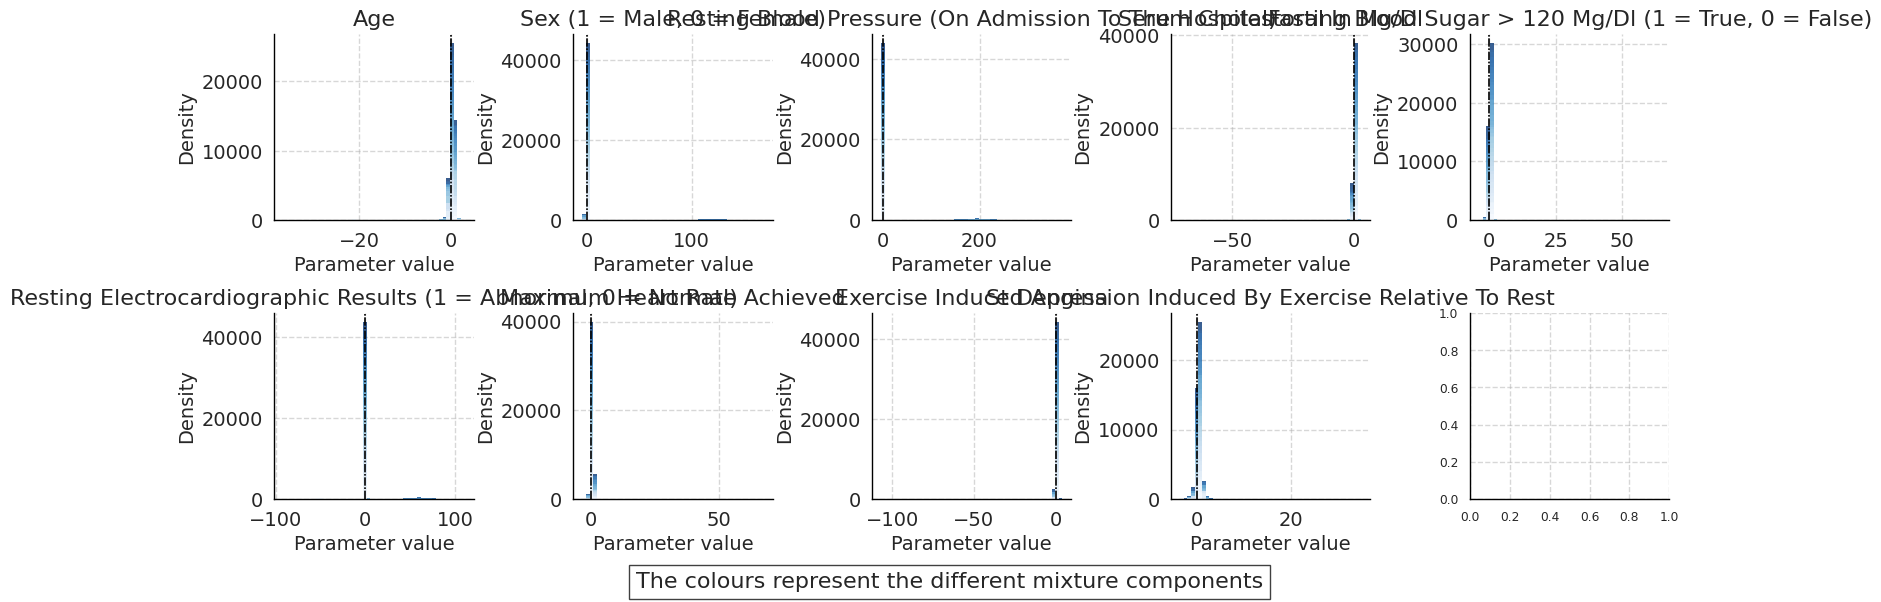

In [24]:
n_features_to_plot = 9

n_rows = 2
n_columns = 5

hist_kwargs = dict(
    bins=50,
    linewidth=0.0,
    stacked=True,
    alpha=0.8,
    color=sns.color_palette("Blues", n_colors=prior_samples.shape[1])
)

fontsize = 14
title_fontsize = 16
with graph_theme():
    fig, axes = plt.subplots(
        n_rows, n_columns, figsize=(3*n_columns, 3*n_rows)
    )

    for feature, ax in zip(
        range(1, n_features_to_plot + 1), # not drawing the intercept
        axes.ravel()
    ):
        ax.hist(
            prior_samples[:, :, feature],
            **hist_kwargs
        )
        ax.set_title(data.keys().tolist()[feature-1].title(), fontsize=title_fontsize)
        ax.set_xlabel("Parameter value", fontsize=fontsize)
        ax.set_ylabel("Density", fontsize=fontsize)
        ax.tick_params("both", labelsize=fontsize)
        ax.axvline(
            x=0.0, 
            linestyle=(0,(5,1,1,1)), 
            color="xkcd:black",
        )

    fig.text(
        x=0.5, y=0.02, 
        s="The colours represent the different mixture components",
        verticalalignment="bottom", horizontalalignment="center", 
        fontsize=title_fontsize,
        bbox=dict(
            facecolor='white', 
            alpha=0.75, 
            edgecolor='black',
            linewidth=1.0,
            pad=5
        ),
    )

    fig.subplots_adjust(
        hspace=0.5, wspace=0.5,
        left=0.05, right=0.98, top=0.95, bottom=0.175
    )

    fig.savefig(
        "./figures/breast_cancer_prior_elicitation.pdf", 
    )

    fig.savefig(
        "./figures/breast_cancer_prior_elicitation.png", 
        dpi=300,
    )

    plt.show()

